# Concise Copy-Paste Augmentation for Drill Bit Body Defects
This notebook implements a Copy-Paste data augmentation tailored for body defects: **Chipped** (1), **Scratched** (2), and **Severe_Rust** (3).

In [109]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import glob

random.seed(42)
np.random.seed(42)

dataset_path = "/Users/mac/Detect_Drill_Bit/final-dataset"
train_images_dir = os.path.join(dataset_path, "train/images")
train_labels_dir = os.path.join(dataset_path, "train/labels")
classes = ['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
target_classes = [1, 2, 3] # Only Chipped (1), Scratched (2), Severe_Rust (3)

In [110]:
def get_class_distribution(labels_dir, ignore_aug=True):
    counts = Counter()
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    for lf in label_files:
        if ignore_aug and os.path.basename(lf).startswith("aug_"):
            continue
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

counts_before = get_class_distribution(train_labels_dir, ignore_aug=True)
print("Defect counts before augmentation:")
for idx, name in enumerate(classes):
    print(f"  {name}: {counts_before[idx]} instances")

Defect counts before augmentation:
  Broken: 747 instances
  Chipped: 1134 instances
  Scratched: 1367 instances
  Severe_Rust: 1205 instances
  Tip_Wear: 907 instances


In [111]:
def crop_rois(images_dir, labels_dir, target_classes):
    rois = {c: [] for c in target_classes}
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    for lf in label_files:
        if os.path.basename(lf).startswith("aug_"):
            continue
        
        img_name = os.path.basename(lf).replace(".txt", ".jpg")
        img_path = os.path.join(images_dir, img_name)
        if not os.path.exists(img_path):
            img_name = img_name.replace(".jpg", ".png")
            img_path = os.path.join(images_dir, img_name)
            if not os.path.exists(img_path):
                continue
                
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h_img, w_img = img.shape[:2]
        
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                if cls_id in target_classes:
                    x_c, y_c, w, h = map(float, parts[1:])
                    x1 = int((x_c - w/2) * w_img)
                    y1 = int((y_c - h/2) * h_img)
                    x2 = int((x_c + w/2) * w_img)
                    y2 = int((y_c + h/2) * h_img)
                    
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w_img, x2), min(h_img, y2)
                    
                    if (x2 - x1) > 2 and (y2 - y1) > 2:
                        roi = img[y1:y2, x1:x2].copy()
                        rois[cls_id].append({
                            'roi': roi,
                            'w_rel': w,
                            'h_rel': h
                        })
    return rois

rois = crop_rois(train_images_dir, train_labels_dir, target_classes)
for c in target_classes:
    print(f"Extracted {len(rois[c])} ROIs for class '{classes[c]}'")

Extracted 1134 ROIs for class 'Chipped'
Extracted 1367 ROIs for class 'Scratched'
Extracted 1205 ROIs for class 'Severe_Rust'


In [112]:
def apply_copy_paste(img, existing_labels, rois, num_pastes=2):
    h_img, w_img = img.shape[:2]
    new_labels = list(existing_labels)
    aug_img = img.copy()
    
    if not existing_labels:
        return None, None
        
    # Create foreground mask using Otsu thresholding
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, fg_mask = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    ref_labels = list(existing_labels)
    random.shuffle(ref_labels)
    
    pastes_done = 0
    for ref_label in ref_labels:
        if pastes_done >= num_pastes:
            break
            
        ref_cls, ref_xc, ref_yc, ref_w, ref_h = ref_label
        cls_id = ref_cls
        
        if cls_id not in rois or not rois[cls_id]:
            continue
            
        roi_info = random.choice(rois[cls_id])
        roi = roi_info['roi'].copy()
        
        # Random flip
        if random.random() > 0.5: roi = cv2.flip(roi, 1)
        if random.random() > 0.5: roi = cv2.flip(roi, 0)
        
        # Scale ROI size
        scale = random.uniform(0.85, 1.1)
        new_w = int(ref_w * w_img * scale)
        new_h = int(ref_h * h_img * scale)
        new_w = np.clip(new_w, 6, int(w_img * 0.25))
        new_h = np.clip(new_h, 6, int(h_img * 0.25))
        roi = cv2.resize(roi, (new_w, new_h))
        
        valid = False
        x_c, y_c = 0, 0
        
        # Shift vertically to place near the anchor but without direct overlap
        for direction in [1, -1]:
            dy_rel = direction * (ref_h * random.uniform(1.1, 1.6))
            dx_rel = random.uniform(-ref_w * 0.2, ref_w * 0.2)
            
            x_c = int((ref_xc + dx_rel) * w_img)
            y_c = int((ref_yc + dy_rel) * h_img)
            
            x1 = x_c - new_w // 2
            y1 = y_c - new_h // 2
            x2 = x_c + new_w // 2
            y2 = y_c + new_h // 2
            
            # Verify bounds and foreground ratio to ensure it is pasted on the drill bit
            if x1 >= 0 and y1 >= 0 and x2 <= w_img and y2 <= h_img:
                overlap = False
                for lbl in new_labels:
                    l_cls, l_xc, l_yc, l_w, l_h = lbl
                    lx1 = int((l_xc - l_w/2) * w_img)
                    ly1 = int((l_yc - l_h/2) * h_img)
                    lx2 = int((l_xc + l_w/2) * w_img)
                    ly2 = int((l_yc + l_h/2) * h_img)
                    
                    ix1 = max(x1, lx1)
                    iy1 = max(y1, ly1)
                    ix2 = min(x2, lx2)
                    iy2 = min(y2, ly2)
                    
                    if ix1 < ix2 and iy1 < iy2:
                        intersection_area = (ix2 - ix1) * (iy2 - iy1)
                        if intersection_area / (new_w * new_h) > 0.1:
                            overlap = True
                            break
                
                if overlap: continue
                
                if np.mean(fg_mask[y1:y2, x1:x2]) / 255.0 > 0.85:
                    valid = True
                    break
        
        if not valid: continue
        
        # Seamless clone
        mask = np.ones(roi.shape[:2], dtype=np.uint8) * 255
        try:
            aug_img = cv2.seamlessClone(roi, aug_img, mask, (x_c, y_c), cv2.MIXED_CLONE)
            new_labels.append([cls_id, x_c/w_img, y_c/h_img, new_w/w_img, new_h/h_img])
            pastes_done += 1
        except:
            continue
            
    return aug_img, new_labels

In [113]:
# Delete old augmented files
for f in glob.glob(os.path.join(train_images_dir, "aug_cp_*")):
    os.remove(f)
for f in glob.glob(os.path.join(train_labels_dir, "aug_cp_*")):
    os.remove(f)
print("Deleted old augmented files.")

# Identify target images to augment (must contain Chipped, Scratched, or Severe_Rust)
original_images = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png')) and not f.startswith("aug_")]
valid_original_images = []

for img_name in original_images:
    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_name)
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        # Check if it contains at least one of target classes
        has_target = False
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts and int(parts[0]) in target_classes:
                    has_target = True
                    break
        if has_target:
            valid_original_images.append(img_name)

print(f"Found {len(valid_original_images)} valid original training images with target body defects.")

num_to_augment = 300
selected_images = random.sample(valid_original_images, min(num_to_augment, len(valid_original_images)))

augmented_count = 0
for img_name in selected_images:
    img_path = os.path.join(train_images_dir, img_name)
    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_name)
    
    img = cv2.imread(img_path)
    if img is None: continue
    
    existing_labels = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts: existing_labels.append([int(parts[0])] + [float(x) for x in parts[1:]])
            
    num_pastes = random.randint(1, 3)
    aug_img, new_labels = apply_copy_paste(img, existing_labels, rois, num_pastes=num_pastes)
    
    if aug_img is None or new_labels is None: continue
    
    new_img_name = f"aug_cp_{img_name}"
    new_label_name = f"aug_cp_{label_name}"
    
    cv2.imwrite(os.path.join(train_images_dir, new_img_name), aug_img)
    with open(os.path.join(train_labels_dir, new_label_name), 'w') as f:
        for lbl in new_labels:
            f.write(f"{lbl[0]} {' '.join(f'{x:.6f}' for x in lbl[1:])}\n")
            
    augmented_count += 1

print(f"Successfully generated and saved {augmented_count} augmented images for body defects.")

Deleted old augmented files.
Found 2550 valid original training images with target body defects.
Successfully generated and saved 300 augmented images for body defects.


In [170]:
counts_after = get_class_distribution(train_labels_dir, ignore_aug=False)
print("Defect counts after body-defect augmentation:")
for idx, name in enumerate(classes):
    diff = counts_after[idx] - counts_before[idx]
    print(f"  {name}: {counts_before[idx]} -> {counts_after[idx]} (+{diff})")

Defect counts after body-defect augmentation:
  Broken: 747 -> 766 (+19)
  Chipped: 1134 -> 1288 (+154)
  Scratched: 1367 -> 1535 (+168)
  Severe_Rust: 1205 -> 1355 (+150)
  Tip_Wear: 907 -> 955 (+48)


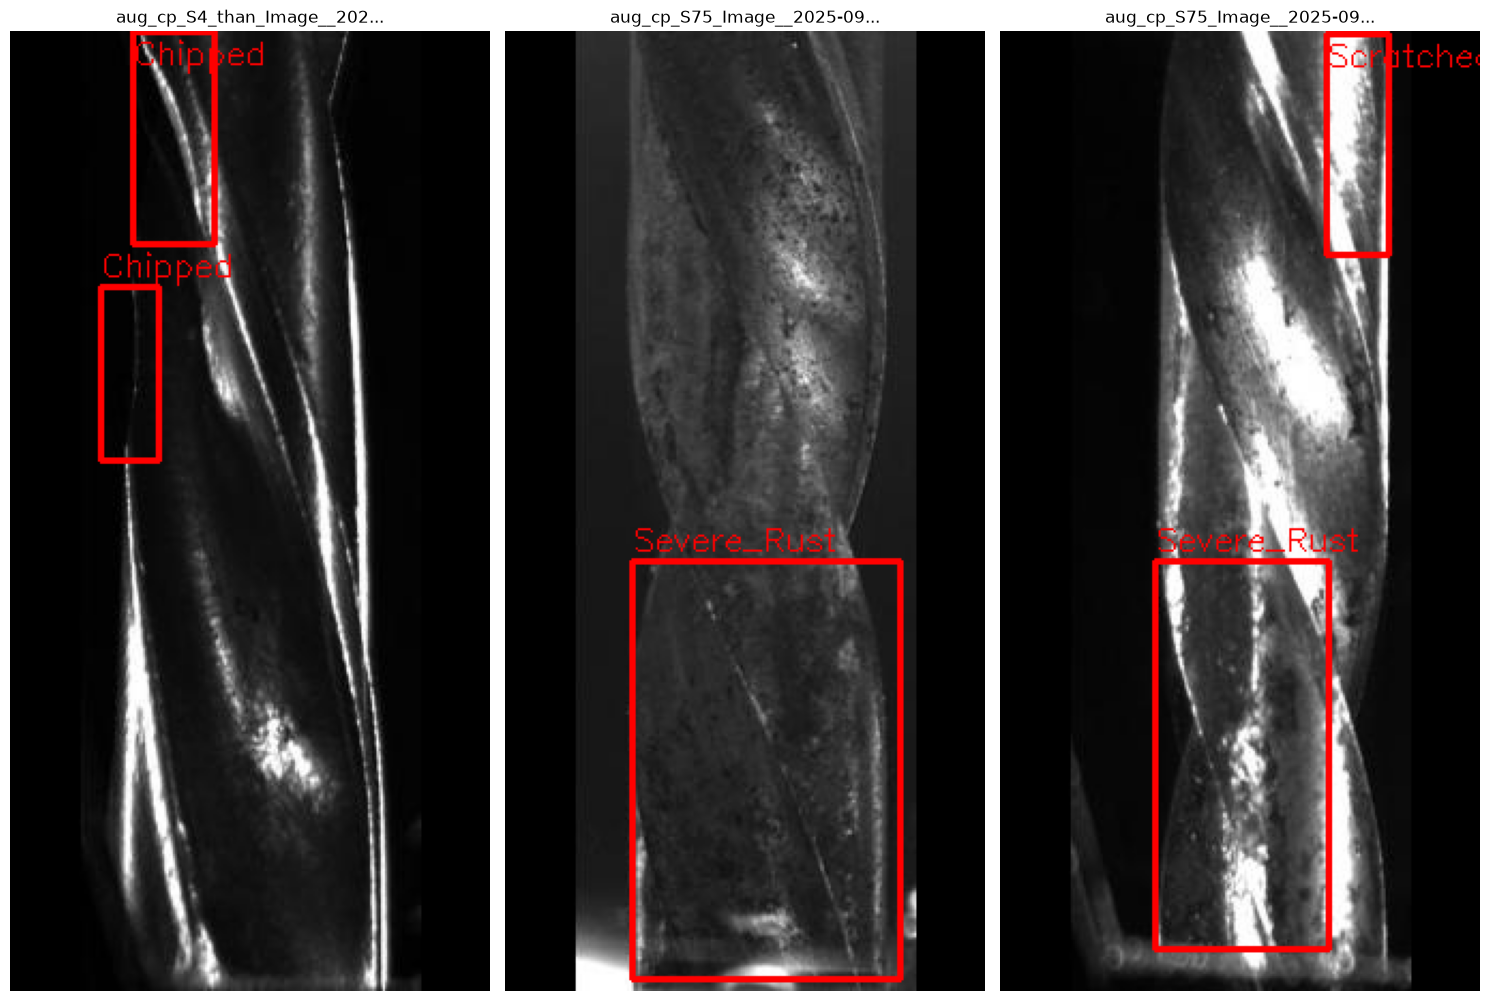

In [168]:
# Select 3 random augmented images and plot them with bounding boxes
aug_label_files = glob.glob(os.path.join(train_labels_dir, "aug_cp_*.txt"))
if aug_label_files:
    plt.figure(figsize=(15, 10))
    selected_aug_labels = random.sample(aug_label_files, min(3, len(aug_label_files)))
    
    for idx, lf in enumerate(selected_aug_labels):
        img_name = os.path.basename(lf).replace(".txt", ".jpg")
        img_path = os.path.join(train_images_dir, img_name)
        if not os.path.exists(img_path):
            img_path = img_path.replace(".jpg", ".png")
            
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]
        
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
                x1 = int((x_c - w/2) * w_img)
                y1 = int((y_c - h/2) * h_img)
                x2 = int((x_c + w/2) * w_img)
                y2 = int((y_c + h/2) * h_img)
                
                # Red box for targeted body defects, Blue box for others
                color = (255, 0, 0) if cls_id in target_classes else (0, 0, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                
                text_y = y1 - 5 if y1 - 5 > 15 else y1 + 15
                cv2.putText(img, classes[cls_id], (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                
        plt.subplot(1, 3, idx + 1)
        plt.imshow(img)
        plt.title(img_name[:25] + "...")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No augmented images found to visualize. Run the augmentation loop first.")